# Sélection de variables — coordonnées MediaPipe

Objectif : comparer plusieurs méthodes de sélection de variables sur `coordonnees_clean.csv`.

Méthodes testées :
1. Feature importance avec **Random Forest**
2. Feature importance avec **XGBoost**
3. Sélection par **régularisation L1**
4. Sélection par **SVM + RFE**

À la fin, on compare les variables qui ressortent le plus souvent ou celles qui au contraire sont très peu discriminantes

## Imports 

In [ ]:
# Imports 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Modèles et sélection de variables
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE

# ACP / PCA
from sklearn.decomposition import PCA

# Métriques
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

RANDOM_STATE = 42

## Chargement du CSV

In [170]:
CSV_PATH = "exports/coordonnees_clean.csv"

df = pd.read_csv(CSV_PATH)
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (284, 85)


,nez_x,nez_y,nez_z,nez_vis,oeil_gauche_x,oeil_gauche_y,oeil_gauche_z,oeil_gauche_vis,oeil_droit_x,oeil_droit_y,oeil_droit_z,oeil_droit_vis,oreille_gauche_x,oreille_gauche_y,oreille_gauche_z,oreille_gauche_vis,oreille_droite_x,oreille_droite_y,oreille_droite_z,oreille_droite_vis,epaule_gauche_x,epaule_gauche_y,epaule_gauche_z,epaule_gauche_vis,epaule_droite_x,epaule_droite_y,epaule_droite_z,epaule_droite_vis,coude_gauche_x,coude_gauche_y,coude_gauche_z,coude_gauche_vis,coude_droit_x,coude_droit_y,coude_droit_z,coude_droit_vis,poignet_gauche_x,poignet_gauche_y,poignet_gauche_z,poignet_gauche_vis,poignet_droit_x,poignet_droit_y,poignet_droit_z,poignet_droit_vis,hanche_gauche_x,hanche_gauche_y,hanche_gauche_z,hanche_gauche_vis,hanche_droite_x,hanche_droite_y,hanche_droite_z,hanche_droite_vis,genou_gauche_x,genou_gauche_y,genou_gauche_z,genou_gauche_vis,genou_droit_x,genou_droit_y,genou_droit_z,genou_droit_vis,cheville_gauche_x,cheville_gauche_y,cheville_gauche_z,cheville_gauche_vis,cheville_droite_x,cheville_droite_y,cheville_droite_z,cheville_droite_vis,talon_gauche_x,talon_gauche_y,talon_gauche_z,talon_gauche_vis,talon_droit_x,talon_droit_y,talon_droit_z,talon_droit_vis,pied_gauche_x,pied_gauche_y,pied_gauche_z,pied_gauche_vis,pied_droit_x,pied_droit_y,pied_droit_z,pied_droit_vis,label
0,0.637621,0.138610,0.233582,0.999896,0.644267,0.119031,0.179639,0.999958,0.651184,0.117968,0.221253,0.999905,0.658861,0.121825,-0.008663,0.999933,0.676635,0.120116,0.178771,0.999929,0.630811,0.216003,-0.113659,0.999924,0.742125,0.226438,0.250747,0.999974,0.579695,0.323499,-0.046928,0.230770,0.729544,0.322628,0.457268,0.047281,0.579535,0.336415,0.222887,0.092411,0.670643,0.297396,0.622107,0.037801,0.567905,0.440322,-0.132421,0.999775,0.620948,0.485307,0.132092,0.999948,0.421189,0.342786,-0.007688,0.966624,0.607213,0.683587,0.210872,0.982059,0.252499,0.292247,0.079139,0.974156,0.616636,0.884979,0.259843,0.995039,0.229521,0.317571,0.089154,0.969566,0.618542,0.914481,0.268425,0.991724,0.201480,0.243661,0.067086,0.914758,0.615645,0.909720,0.222452,0.971388,ap_tchagui
1,0.269730,0.257379,-0.114015,0.999281,0.261025,0.242842,-0.074119,0.999220,0.243149,0.248696,-0.117047,0.999098,0.249863,0.256067,0.133121,0.996826,0.208939,0.269285,-0.059929,0.999367,0.343602,0.325835,0.304861,0.999866,0.198470,0.378694,-0.137537,0.999944,0.481204,0.357233,0.249011,0.406855,0.336028,0.434665,-0.279777,0.955339,0.485047,0.283434,-0.019082,0.549412,0.418837,0.333218,-0.308527,0.912115,0.485030,0.496223,0.111620,0.999873,0.421646,0.549871,-0.112107,0.999919,0.556498,0.465573,0.035193,0.884316,0.531499,0.711204,0.002241,0.905460,0.651428,0.408756,-0.027015,0.971182,0.576181,0.848730,0.151646,0.795450,0.681122,0.405885,-0.043195,0.959354,0.562040,0.871316,0.162703,0.752584,0.644928,0.377261,-0.212476,0.969100,0.617407,0.870777,0.008565,0.859083,ap_tchagui
2,0.561428,0.165053,0.214194,0.999961,0.572796,0.145410,0.166621,0.999978,0.577162,0.146304,0.206116,0.999946,0.589125,0.149343,-0.008461,0.999953,0.600202,0.149610,0.168913,0.999948,0.568778,0.248855,-0.120343,0.999977,0.668403,0.258166,0.219682,0.999993,0.526372,0.366793,-0.213030,0.845878,0.607905,0.382140,0.258069,0.201924,0.524079,0.471982,-0.170532,0.662537,0.553256,0.453123,0.214548,0.279889,0.497681,0.461892,-0.109432,0.999954,0.542620,0.504566,0.109788,0.999990,0.358221,0.362019,-0.001340,0.990126,0.534509,0.705341,0.165522,0.996203,0.211572,0.283460,0.081799,0.994177,0.541183,0.912203,0.242902,0.996865,0.193005,0.282521,0.085926,0.989619,0.537759,0.937577,0.249350,0.994461,0.176738,0.213497,0.011807,0.989347,0.547044,0.946837,0.178241,0.991011,ap_tchagui
3,0.448500,0.242430,0.075736,0.999923,0.435312,0.229039,0.122694,0.999854,0.425200,0.230837,0.050862,0.999940,0.399928,0.243526,0.305615,0.999749,0.379280,0.244713,-0.016470,0.999845,0.421189,0.351085,0.508321,0.999955,0.342212,0.348051,-0.184290,0.999989,0.522743,0.491289,0.532143,0.170002,0.354522,0.479762,-0.339284,0.896081,0.634659,0.515283,0.319666,0.403738,

## Identification de la cible et des variables numériques

In [171]:
# Colonne cible
TARGET_COL = "label"

print("Colonne cible :", TARGET_COL)
print(df[TARGET_COL].value_counts())

# On ne garde que les colonnes numériques comme variables explicatives.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

print("Nombre de variables numériques :", len(numeric_cols))

Colonne cible : label
label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64
Nombre de variables numériques : 84


## Préparation de X et y

On sépare les variables explicatives `X` et la classe `y`, puis on encode les labels.

In [172]:
# Sélection des variables numériques comme variables prédictives
X = df[numeric_cols].copy()

# Sélection de la variable cible
y_raw = df[TARGET_COL].copy()

# Encodage des labels au format numérique
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (213, 84)
Test  : (71, 84)


## Fonction utilitaire

Cette fonction affiche les variables les plus importantes pour chaque méthode.

In [173]:
# Retourne les variables triées par importance
def get_top_features(importances_df, score_col, top_n=None):
    df_sorted = importances_df.sort_values(
        score_col,
        ascending=False
    )

    if top_n is not None:
        return df_sorted.head(top_n)

    return df_sorted

In [174]:
# Affiche un graphique des variables les plus importantes et à côté un graphique des variables les moins importantes
def plot_top_features(importances_df, title, score_col, top_n=20):
    top = get_top_features(
        importances_df,
        score_col=score_col,
        top_n=top_n
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x=score_col,
        y="feature"
    )
    plt.title(title)
    plt.show()

# Méthode 1 — Random Forest

La Random Forest donne une importance de variables. Elle capte des relations non linéaires.

In [175]:
# Déclaration du modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=500, #nb d'arbres
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Entraînement du modèle sur les données d'apprentissage
rf.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred_rf = rf.predict(X_test)


In [176]:
# Évaluation globale du modèle
print("Accuracy Random Forest :", accuracy_score(y_test, y_pred_rf))

# Rapport détaillé :
# - precision : parmi les prédictions d'une classe, combien sont correctes
# - recall : parmi les vraies observations d'une classe, combien sont retrouvées
# - f1-score : compromis entre precision et recall
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
print("Matrice de confusion :")
print(cm)

Accuracy Random Forest : 0.9436619718309859
              precision    recall  f1-score   support

  ap_tchagui       0.94      0.94      0.94        35
 yop_tchagui       0.94      0.94      0.94        36

    accuracy                           0.94        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.94      0.94      0.94        71

Matrice de confusion :
[[33  2]
 [ 2 34]]


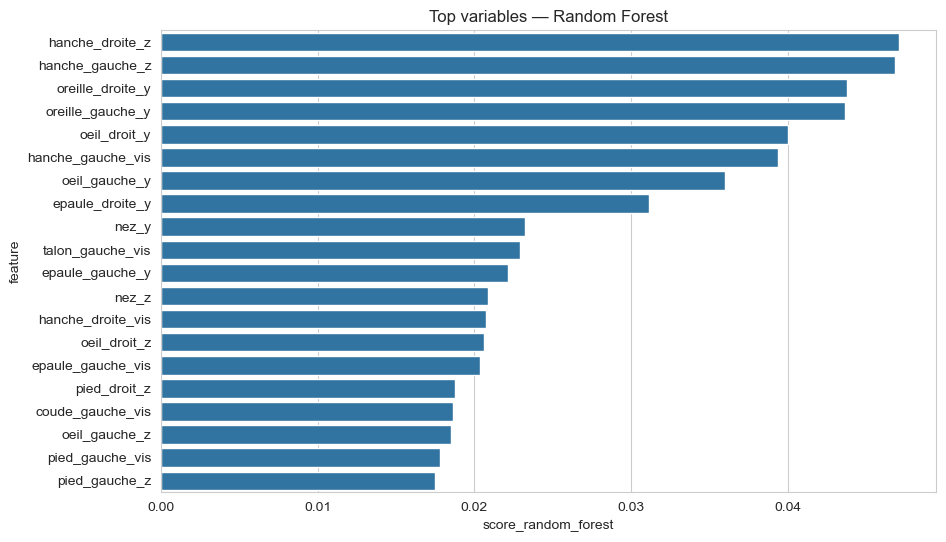

,feature,score_random_forest
50,hanche_droite_z,0.047125
46,hanche_gauche_z,0.046871
17,oreille_droite_y,0.043791
13,oreille_gauche_y,0.043644
9,oeil_droit_y,0.040043
47,hanche_gauche_vis,0.039405
5,oeil_gauche_y,0.036031
25,epaule_droite_y,0.031126
1,nez_y,0.023266
71,talon_gauche_vis,0.022909


In [177]:
# Récupération de l'importance des variables 
# Chaque score indique à quel point une variable a été utile pour séparer les classes.
method = "random_forest"
score_col = f"score_{method}"

rf_importances = pd.DataFrame({
    "feature": X.columns,
    score_col: rf.feature_importances_
}).sort_values(score_col, ascending=False)

# Affichage du graphique (top 20)
plot_top_features(
    rf_importances,
    "Top variables — Random Forest",
    score_col=score_col,
    top_n=20
)

# Affichage du tableau complet (84 variables)
display(
    get_top_features(
        rf_importances,
        score_col=score_col
    )
)

# Méthode 2 — XGBoost


In [178]:
# Import du modèle XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Déclaration du modèle XGBoost
# XGBoost construit plusieurs arbres de décision successifs.
# Chaque nouvel arbre essaie de corriger les erreurs des arbres précédents.
xgb = XGBClassifier(
    n_estimators=300,        # Nombre d'arbres construits
    learning_rate=0.05,      # Vitesse d'apprentissage : plus faible = apprentissage plus progressif
    max_depth=3,             # Profondeur maximale des arbres
    subsample=0.9,           # Pourcentage des lignes utilisées à chaque arbre
    colsample_bytree=0.9,    # Pourcentage des variables utilisées à chaque arbre
    random_state=RANDOM_STATE,
    eval_metric="logloss"    # Métrique utilisée pendant l'entraînement
)

# Entraînement du modèle sur les données d'apprentissage
xgb.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred_xgb = xgb.predict(X_test)

In [179]:
# Évaluation globale du modèle
print("Accuracy XGBoost :", accuracy_score(y_test, y_pred_xgb))

# Rapport détaillé des performances par classe
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

# Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Matrice de confusion :")
print(cm_xgb)


Accuracy XGBoost : 0.9436619718309859
              precision    recall  f1-score   support

  ap_tchagui       0.97      0.91      0.94        35
 yop_tchagui       0.92      0.97      0.95        36

    accuracy                           0.94        71
   macro avg       0.95      0.94      0.94        71
weighted avg       0.95      0.94      0.94        71

Matrice de confusion :
[[32  3]
 [ 1 35]]


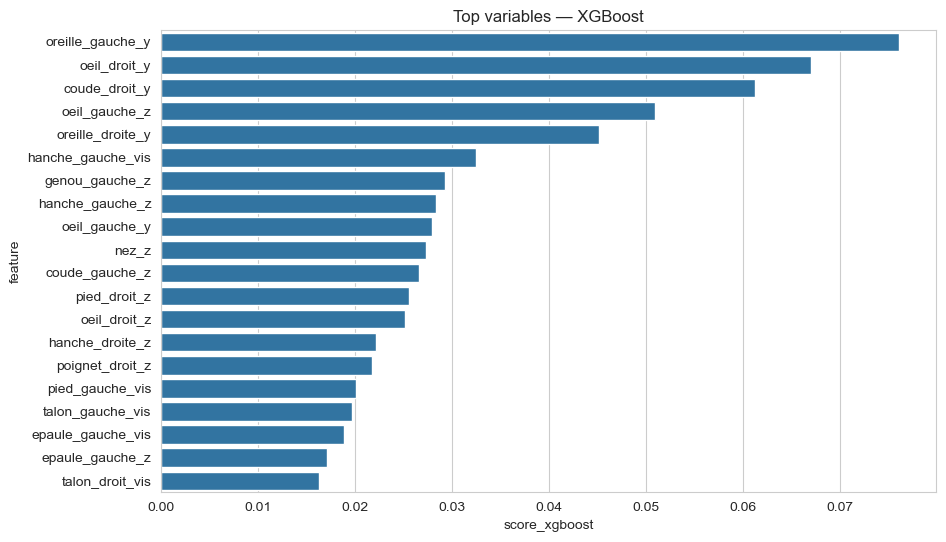

,feature,score_xgboost
13,oreille_gauche_y,0.076068
9,oeil_droit_y,0.066967
33,coude_droit_y,0.061221
6,oeil_gauche_z,0.050953
17,oreille_droite_y,0.045105
47,hanche_gauche_vis,0.032485
54,genou_gauche_z,0.029265
46,hanche_gauche_z,0.028300
5,oeil_gauche_y,0.027962
2,nez_z,0.027352


In [180]:
# Récupération de l'importance des variables
method = "xgboost"
score_col = f"score_{method}"

xgb_importances = pd.DataFrame({
    "feature": X.columns,
    score_col: xgb.feature_importances_
}).sort_values(score_col, ascending=False)

# Affichage du graphique (top 20)
plot_top_features(
    xgb_importances,
    "Top variables — XGBoost",
    score_col=score_col,
    top_n=20
)

# Affichage du tableau complet
display(
    get_top_features(
        xgb_importances,
        score_col=score_col
    )
)

# Méthode 3 — Régularisation L1

Pour une classification, on utilise une régression logistique avec pénalité L1. La L1 pousse certains coefficients à zéro : les variables restantes sont donc considérées comme utiles.

Contrairement aux méthodes basées sur les arbres (Random Forest et XGBoost), la régularisation L1 réalise une véritable sélection de variables en annulant complètement les coefficients des variables jugées peu informatives. Cela permet d'obtenir un modèle plus simple et plus interprétable.

In [181]:
# Pipeline :
# - Standardisation des variables
# - Régression logistique avec régularisation L1 (Lasso)

l1_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,  # plus C est petit, plus la sélection est agressive
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000
    ))
])

# Entraînement du modèle
l1_model.fit(X_train, y_train)

# Prédiction sur le jeu de test
y_pred_l1 = l1_model.predict(X_test)

c:\Users\Lily\.conda\envs\data\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Lily\.conda\envs\data\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [182]:
# Évaluation globale
print("Accuracy L1 Logistic Regression :", accuracy_score(y_test, y_pred_l1))

# Rapport détaillé
print(classification_report(
    y_test,
    y_pred_l1,
    target_names=label_encoder.classes_
))

# Matrice de confusion
cm_l1 = confusion_matrix(y_test, y_pred_l1)
print("Matrice de confusion :")
print(cm_l1)


Accuracy L1 Logistic Regression : 0.9014084507042254
              precision    recall  f1-score   support

  ap_tchagui       0.85      0.97      0.91        35
 yop_tchagui       0.97      0.83      0.90        36

    accuracy                           0.90        71
   macro avg       0.91      0.90      0.90        71
weighted avg       0.91      0.90      0.90        71

Matrice de confusion :
[[34  1]
 [ 6 30]]


In [183]:
# Récupération des coefficients du modèle
coef = l1_model.named_steps["model"].coef_

# Cas binaire : une seule ligne de coefficients
if coef.shape[0] == 1:
    scores = np.abs(coef[0])
else:
    scores = np.mean(np.abs(coef), axis=0)

# Construction du tableau des importances
method = "l1_logistic_regression"
score_col = f"score_{method}"

l1_importances = pd.DataFrame({
    "feature": X.columns,
    score_col: scores
}).sort_values(score_col, ascending=False)

# Nombre de variables conservées (coefficient différent de zéro)
print(
    "Nombre de variables avec coefficient non nul :",
    (l1_importances[score_col] > 0).sum()
)

# Tableau complet
display(
    get_top_features(
        l1_importances,
        score_col=score_col
    )
)

Nombre de variables avec coefficient non nul : 11


,feature,score_l1_logistic_regression
17,oreille_droite_y,1.229287
35,coude_droit_vis,0.499475
54,genou_gauche_z,0.370888
49,hanche_droite_y,0.361812
31,coude_gauche_vis,0.354941
41,poignet_droit_y,0.174865
82,pied_droit_z,0.161104
19,oreille_droite_vis,0.097463
45,hanche_gauche_y,0.094991
66,cheville_droite_z,0.053266


# Méthode 4 — SVM + RFE

RFE signifie Recursive Feature Elimination. On entraîne un modèle, on retire les variables les moins utiles, puis on recommence.

Ici, on utilise un SVM linéaire avec données standardisées.

In [184]:
# Nombre de variables que l'on souhaite conserver
N_FEATURES_TO_SELECT = min(20, X.shape[1])

# Déclaration du modèle 
svm_estimator = LinearSVC(
    C=0.1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=10000,
    dual=False
)

# Standardisation des données
# Le SVM est sensible à l'échelle des variables.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Déclaration de la méthode RFE (Recursive Feature Elimination)
# Principe : le modèle est entraîné avec toutes les variables, la variable la moins utile est retirée, le modèle est ré-entraîné, on répète jusqu'à conserver n_variables
rfe = RFE(
    estimator=svm_estimator,
    n_features_to_select=N_FEATURES_TO_SELECT,
    step=1
)

# Entraînement 
rfe.fit(X_train_scaled, y_train)



,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearSVC(C=0...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'


In [185]:
# Prédiction sur le jeu de test
y_pred_rfe = rfe.predict(X_test_scaled)

In [186]:
# Évaluation globale
print("Accuracy SVM + RFE :", accuracy_score(y_test, y_pred_rfe))

# Rapport détaillé des performances
print(classification_report(
    y_test,
    y_pred_rfe,
    target_names=label_encoder.classes_
))

# Matrice de confusion 
cm_rfe = confusion_matrix(y_test, y_pred_rfe)
print("Matrice de confusion :")
print(cm_rfe)

Accuracy SVM + RFE : 0.9154929577464789
              precision    recall  f1-score   support

  ap_tchagui       0.94      0.89      0.91        35
 yop_tchagui       0.89      0.94      0.92        36

    accuracy                           0.92        71
   macro avg       0.92      0.92      0.92        71
weighted avg       0.92      0.92      0.92        71

Matrice de confusion :
[[31  4]
 [ 2 34]]


In [187]:
# Création d'un tableau récapitulatif des variables
method = "svm_rfe"
rank_col = f"rank_{method}"

rfe_importances = pd.DataFrame({
    "feature": X.columns,
    rank_col: rfe.ranking_
})

# rank = 1 : variable conservée jusqu'à la fin par RFE
# Plus le rang est élevé, plus la variable a été éliminée tôt et moins elle est jugée pertinente par l'algorithme.
rfe_importances = rfe_importances.sort_values(
    rank_col,
    ascending=True
)

# Affichage du tableau complet
display(rfe_importances)

,feature,rank_svm_rfe
41,poignet_droit_y,1
40,poignet_droit_x,1
49,hanche_droite_y,1
36,poignet_gauche_x,1
35,coude_droit_vis,1
54,genou_gauche_z,1
31,coude_gauche_vis,1
30,coude_gauche_z,1
28,coude_gauche_x,1
55,genou_gauche_vis,1


# Comparaison des résultats


In [188]:
# Comparaison des méthodes de sélection / importance
comparison_importances = (
    rf_importances
    .merge(xgb_importances, on="feature", how="outer")
    .merge(l1_importances, on="feature", how="outer")
    .merge(rfe_importances, on="feature", how="outer")
    .sort_values(
        "score_random_forest",
        ascending=False
    )
)

display(comparison_importances)

,feature,score_random_forest,score_xgboost,score_l1_logistic_regression,rank_svm_rfe
35,hanche_droite_z,0.047125,0.022153,0.000000,54
39,hanche_gauche_z,0.046871,0.028300,0.000000,48
54,oreille_droite_y,0.043791,0.045105,1.229287,2
58,oreille_gauche_y,0.043644,0.076068,0.000000,29
46,oeil_droit_y,0.040043,0.066967,0.000000,52
36,hanche_gauche_vis,0.039405,0.032485,0.000000,23
50,oeil_gauche_y,0.036031,0.027962,0.000000,30
18,epaule_droite_y,0.031126,0.012945,0.000000,1
42,nez_y,0.023266,0.004723,0.000000,46
80,talon_gauche_vis,0.022909,0.019691,0.000000,1


In [189]:
# Création du tableau de comparaison
comparison = (
    rf_importances
    .merge(xgb_importances, on="feature")
    .merge(l1_importances, on="feature")
    .merge(rfe_importances, on="feature")
)

# Rangs pour RF et XGBoost
comparison["rank_rf"] = comparison["score_random_forest"].rank(
    ascending=False,
    method="min"
)

comparison["rank_xgb"] = comparison["score_xgboost"].rank(
    ascending=False,
    method="min"
)

# RFE possède déjà un rang
comparison["rank_rfe"] = comparison["rank_svm_rfe"]

# Fonction de catégorisation
def rank_category(rank):
    if rank <= 10:
        return "Top 10"
    elif rank <= 20:
        return "11-20"
    elif rank <= 40:
        return "21-40"
    elif rank <= 60:
        return "41-60"
    else:
        return ">60"

# Catégories RF, XGB et RFE
comparison["RF"] = comparison["rank_rf"].apply(rank_category)
comparison["XGB"] = comparison["rank_xgb"].apply(rank_category)
comparison["RFE"] = comparison["rank_rfe"].apply(rank_category)

# L1 : coefficient arrondi avec les zéros bien visibles
comparison["L1"] = comparison["score_l1_logistic_regression"].apply(
    lambda x: 0 if abs(x) < 1e-6 else round(x, 4)
)

# Tableau final
feature_consensus = comparison[
    [
        "feature",
        "rank_rf",
        "RF",
        "XGB",
        "L1",
        "RFE"
    ]
]

# Affichage trié selon l'importance Random Forest
display(
    feature_consensus
    .sort_values("rank_rf", ascending=True)
    .drop(columns="rank_rf")
)

,feature,RF,XGB,L1,RFE
0,hanche_droite_z,Top 10,11-20,0.0000,41-60
1,hanche_gauche_z,Top 10,Top 10,0.0000,41-60
2,oreille_droite_y,Top 10,Top 10,1.2293,Top 10
3,oreille_gauche_y,Top 10,Top 10,0.0000,21-40
4,oeil_droit_y,Top 10,Top 10,0.0000,41-60
5,hanche_gauche_vis,Top 10,Top 10,0.0000,21-40
6,oeil_gauche_y,Top 10,Top 10,0.0000,21-40
7,epaule_droite_y,Top 10,21-40,0.0000,Top 10
8,nez_y,Top 10,41-60,0.0000,41-60
9,talon_gauche_vis,Top 10,11-20,0.0000,Top 10


In [190]:
# Voir la ou les variables sont basse partout
low_features = feature_consensus[
    (feature_consensus["RF"] == ">60")
    & (feature_consensus["XGB"] == ">60")
    & (feature_consensus["RFE"] == ">60")
    & (feature_consensus["L1"] == 0)
]

display(low_features)

,feature,rank_rf,RF,XGB,L1,RFE
82,epaule_droite_x,83.0,>60,>60,0.0,>60


In [191]:
# Création du tableau de comparaison
comparison = (
    rf_importances
    .merge(xgb_importances, on="feature")
    .merge(l1_importances, on="feature")
    .merge(rfe_importances, on="feature")
)

# Rangs RF et XGB
comparison["rank_rf"] = comparison["score_random_forest"].rank(
    ascending=False,
    method="min"
)

comparison["rank_xgb"] = comparison["score_xgboost"].rank(
    ascending=False,
    method="min"
)

# Rang RFE déjà disponible
comparison["rank_rfe"] = comparison["rank_svm_rfe"]


# Fonction de catégorisation
def rank_category(rank):
    if rank <= 10:
        return "Top 10"
    elif rank <= 20:
        return "11-20"
    elif rank <= 40:
        return "21-40"
    elif rank <= 60:
        return "41-60"
    else:
        return ">60"


# Catégories RF, XGB et RFE
comparison["RF"] = comparison["rank_rf"].apply(rank_category)
comparison["XGB"] = comparison["rank_xgb"].apply(rank_category)
comparison["RFE"] = comparison["rank_rfe"].apply(rank_category)

# Coefficients L1
comparison["L1"] = comparison["score_l1_logistic_regression"].apply(
    lambda x: 0 if abs(x) < 1e-6 else round(x, 4)
)

# Nombre de méthodes qui considèrent la variable comme peu pertinente
comparison["nb_low"] = (
    (comparison["RF"] == ">60").astype(int)
    + (comparison["XGB"] == ">60").astype(int)
    + (comparison["RFE"] == ">60").astype(int)
    + (comparison["L1"] == 0).astype(int)
)

# Tableau synthétique
feature_consensus = (
    comparison[
        [
            "feature",
            "rank_rf",
            "RF",
            "XGB",
            "L1",
            "RFE",
            "nb_low"
        ]
    ]
    .sort_values(
        ["nb_low", "rank_rf"],
        ascending=[False, True]
    )
)

display(
    feature_consensus.drop(columns="rank_rf")
)

,feature,RF,XGB,L1,RFE,nb_low
82,epaule_droite_x,>60,>60,0.0000,>60,4
61,oreille_gauche_z,>60,>60,0.0000,41-60,3
62,oreille_droite_x,>60,>60,0.0000,41-60,3
64,genou_gauche_y,>60,41-60,0.0000,>60,3
66,talon_droit_x,>60,>60,0.0000,Top 10,3
67,oreille_gauche_x,>60,41-60,0.0000,>60,3
72,talon_gauche_x,>60,>60,0.0000,11-20,3
76,pied_droit_x,>60,>60,0.0000,21-40,3
77,talon_gauche_y,>60,>60,0.0000,Top 10,3
78,pied_gauche_y,>60,>60,0.0000,Top 10,3


## Conclusion 

Les résultats montrent que les coordonnées contiennent déjà un signal fort pour distinguer les techniques. Les modèles obtiennent de bonnes performances, autour de 90 à 94 %, malgré un jeu de données encore limité. 

Plusieurs méthodes sélectionnent des variables similaires. Les variables importantes sont principalement des coordonnées y et z, ce qui est cohérent : y capture la hauteur des articulations dans l’image, z donne une indication d’orientation du corps. Les coordonnées x, liées à la position gauche-droite, semblent moins discriminantes, ce qui confirme que le dataste permet de répondre à cette diversité et qu'il n'y a pas de surapprentissage d'un côté ou de l'autre pour les techniques.

Il peut être intéressant de ne pas réduire trop le nombre de variables, afin de tester par exemple des modèles plus complexes tel qu'un réseau de neuronnes. Ces analyses vont donc nous permettre de supprimer les variables réellement inutile plutôt que de ce limiter aux tops variables.

## Sélection des variables

L’objectif n’est donc pas de supprimer les variables hors du Top 20, mais d’identifier les variables systématiquement peu utiles selon plusieurs méthodes. 

Les variables ayant un nb_low >= 3 peuvent être considérées comme candidates à la suppression, car elles sont jugées faibles par au moins trois méthodes différentes.

In [192]:
# Liste des variables candidates à la suppression
features_to_remove = (
    feature_consensus
    .loc[feature_consensus["nb_low"] >= 3, "feature"]
    .tolist()
)

print("Nombre de variables à supprimer :", len(features_to_remove))
print(features_to_remove)

Nombre de variables à supprimer : 13
['epaule_droite_x', 'oreille_gauche_z', 'oreille_droite_x', 'genou_gauche_y', 'talon_droit_x', 'oreille_gauche_x', 'talon_gauche_x', 'pied_droit_x', 'talon_gauche_y', 'pied_gauche_y', 'oeil_gauche_vis', 'cheville_droite_vis', 'coude_droit_x']


In [193]:
# Copie du DataFrame d'origine
df_reduction = df.copy()

# Suppression des colonnes peu informatives
df_reduction = df_reduction.drop(
    columns=features_to_remove,
    errors="ignore"
)

print("Dimensions avant réduction :", df.shape)
print("Dimensions après réduction :", df_reduction.shape)

Dimensions avant réduction : (284, 85)
Dimensions après réduction : (284, 72)


In [195]:
# Export CSV
df_reduction.to_csv("exports/coordonnees_reduction.csv",index=False)